In [1]:
!pip install pillow

Defaulting to user installation because normal site-packages is not writeable


In [75]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.cm as cm
from scipy import signal

**The governing equation is:**
$$\frac{\partial z}{\partial t} = U + D\frac{\partial^2 z}{\partial x^2}$$
**However, we will ignore uplift for the first part of the lab**

**First, we define our x axis**

In [4]:
L = 100.0
nx = 500
dx = L / (nx - 1)
x = np.linspace(0.1, L, nx)

**The first scenario we will look at is a simple linear slope with a stream at the bottom (right)**

In [5]:
z_line_init = np.linspace(100, 0, nx)

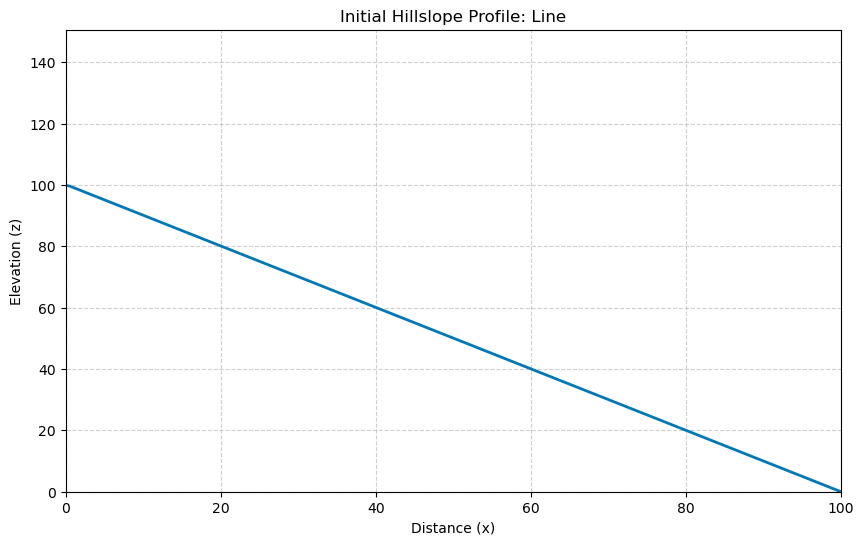

In [83]:
fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot(x, z_line_init, color='#0077b6', lw=2)

ax.set_title(f'Initial Hillslope Profile: Line')
ax.set_xlabel('Distance (x)')
ax.set_ylabel('Elevation (z)')
ax.set_xlim(0, max(x))
ax.set_ylim(0, np.max(z_line_init) * 1.5 + 1) 
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

**We define our diffusivity constant**

In [7]:
D = .01

**And our time/timestep parameters for the model run**

In [8]:
time_per_simulation = 100000
dt = 0.4 * (dx**2) / D
num_steps = int(time_per_simulation / dt)
save_interval = 100

**Now, we run our model**

In [87]:
z_line_store = [z_line_init.copy()]
z = z_line_init

for step in range(num_steps):

    d2zdx2 = np.zeros(nx)
    d2zdx2[1:-1] = (z[2:] - 2 * z[1:-1] + z[:-2]) / (dx**2)   # central difference formula for second derivative
    
    z += (D * d2zdx2) * dt                                    # hillslope diffusion equation
    
    z[-1] = 0.0                                               # right boundary condition, fixes base level (stream condition)
    z[0] = z[1]                                               # left boundary condition, no diffusion at hill top
    
    z = np.maximum(z, 0)
    
    if step % save_interval == 0:
        z_line_store.append(z.copy())

z_line_final = z.copy()

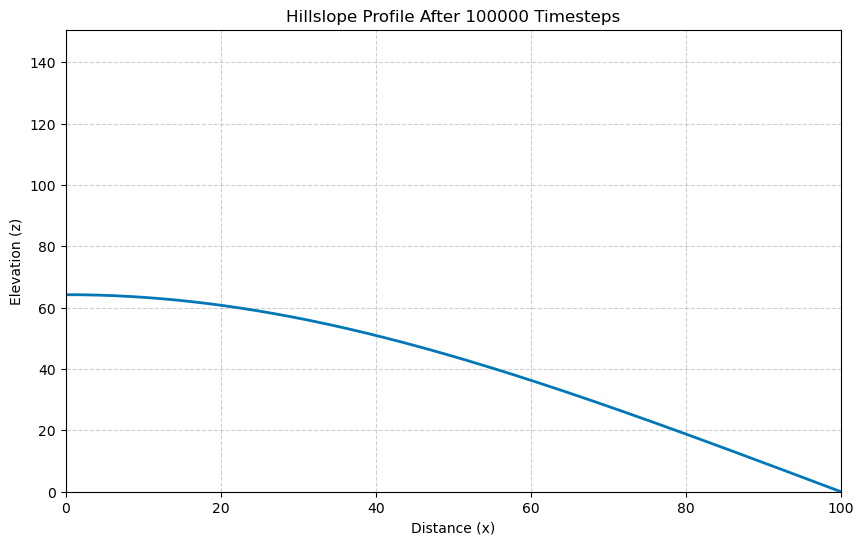

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot(x, z_line_final, color='#0077b6', lw=2)

ax.set_title(f'Hillslope Profile After {time_per_simulation} Timesteps')
ax.set_xlabel('Distance (x)')
ax.set_ylabel('Elevation (z)')
ax.set_xlim(0, max(x))
ax.set_ylim(0, np.max(z_line_init) * 1.5 + 1) 
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

**We also save the animation and plot our profile through time**

In [12]:
def update(frame):
    line.set_ydata(z_line_store[frame])
    ax.set_title(f'Hillslope Evolution - Time: {frame * save_interval * dt:.0f}')
    return line,

ani = FuncAnimation(fig, update, frames=len(z_line_store), interval=50, blit=True)

print("Saving animation... this may take a moment.")
ani.save('hillslope_evolution_line.gif', writer='pillow', fps=20)
print("Animation saved as hillslope_evolution_line.gif")

Saving animation... this may take a moment.
Animation saved as hillslope_evolution_line.gif


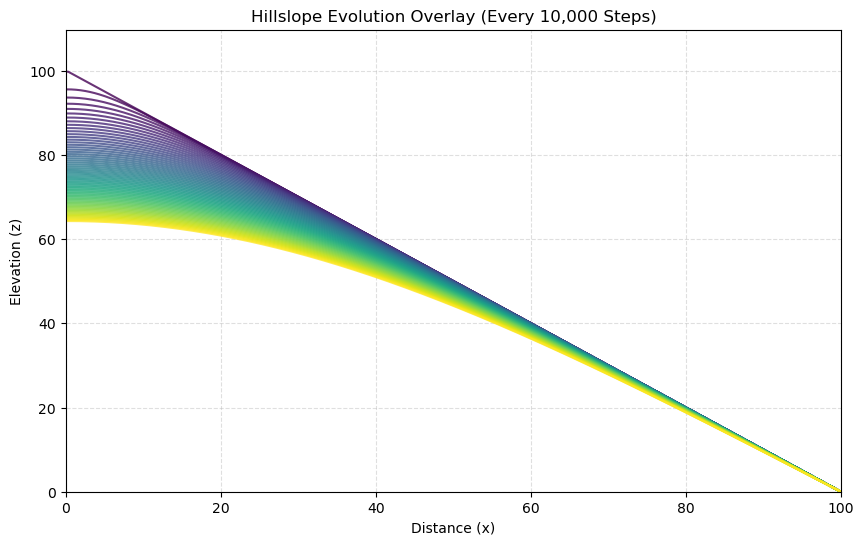

In [80]:
steps_per_overlay = 1000
frame_step = steps_per_overlay // save_interval

fig, ax = plt.subplots(figsize=(10, 6))

colors = cm.viridis(np.linspace(0, 1, len(z_line_store[::frame_step])))

for i, frame_idx in enumerate(range(0, len(z_line_store), frame_step)):
    ax.plot(x, z_line_store[frame_idx], 
            color=colors[i], 
            label=f'Step {frame_idx * save_interval}',
            alpha=0.8)

ax.set_title(f'Hillslope Evolution Overlay (Every {steps_per_overlay} Steps)')
ax.set_xlabel('Distance (x)')
ax.set_ylabel('Elevation (z)')
ax.set_xlim(0, L)
ax.set_ylim(0, np.max(z_line_store[0]) * 1.1)
ax.grid(True, linestyle='--', alpha=0.4)

plt.show()

**Now, we investigate a ridge scenario with two streams on either side**

In [13]:
frequency = .01      
amplitude = 50      
z_ridge_init = amplitude * signal.sawtooth(2 * np.pi * frequency * x, width=0.5) + amplitude

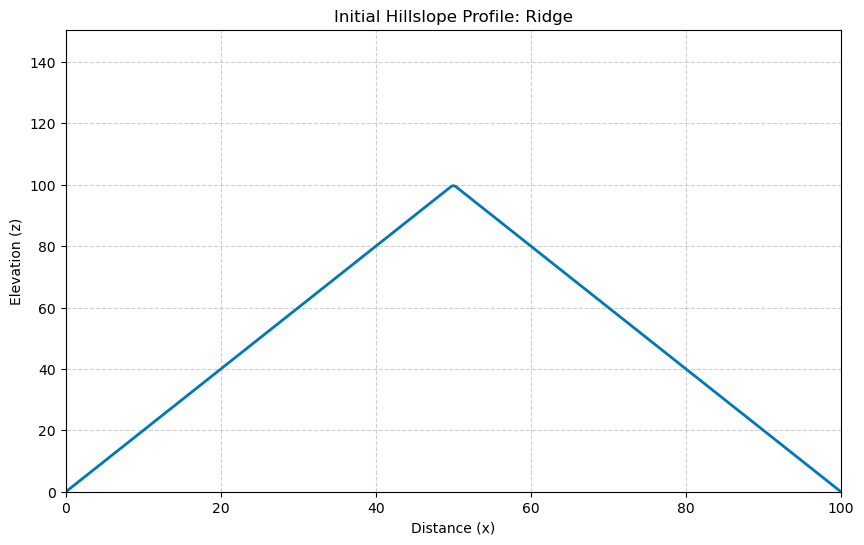

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot(x, z_ridge_init, color='#0077b6', lw=2)

ax.set_title(f'Initial Hillslope Profile: Ridge')
ax.set_xlabel('Distance (x)')
ax.set_ylabel('Elevation (z)')
ax.set_xlim(0, max(x))
ax.set_ylim(0, np.max(z_ridge_init) * 1.5 + 1) 
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

**Our modeling steps remain the same, but notice how the boundary conditions change**

In [15]:
D = .01

In [16]:
time_per_simulation = 100000
dt = 0.4 * (dx**2) / D
num_steps = int(time_per_simulation / dt)
save_interval = 100

In [17]:
z_ridge_store = [z_ridge_init.copy()]
z = z_ridge_init

for step in range(num_steps):

    d2zdx2 = np.zeros(nx)
    d2zdx2[1:-1] = (z[2:] - 2 * z[1:-1] + z[:-2]) / (dx**2)   # central difference formula for second derivative
    
    z += (D * d2zdx2) * dt                                    # hillslope diffusion equation
    
    z[-1] = 0.0                                               # right boundary condition, fixes base level (right side stream)
    z[0] = 0.0                                                # left boundary condition, fixes base level (left side stream)
    
    z = np.maximum(z, 0)
    
    if step % save_interval == 0:
        z_ridge_store.append(z.copy())

z_ridge_final = z.copy()

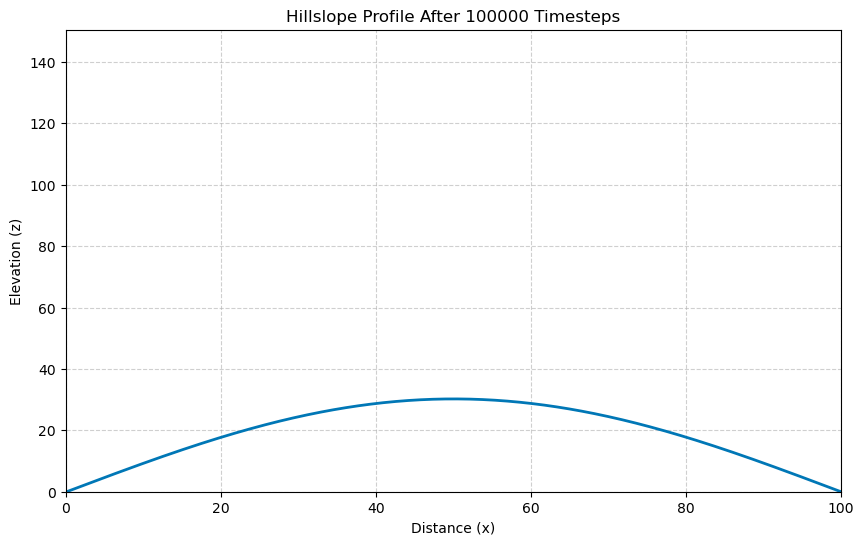

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot(x, z_ridge_final, color='#0077b6', lw=2)

ax.set_title(f'Hillslope Profile After {time_per_simulation} Timesteps')
ax.set_xlabel('Distance (x)')
ax.set_ylabel('Elevation (z)')
ax.set_xlim(0, max(x))
ax.set_ylim(0, np.max(z_ridge_init) * 1.5 + 1) 
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [19]:
def update(frame):
    line.set_ydata(z_ridge_store[frame])
    ax.set_title(f'Hillslope Evolution - Time: {frame * save_interval * dt:.0f}')
    return line,

ani = FuncAnimation(fig, update, frames=len(z_ridge_store), interval=50, blit=True)

print("Saving animation... this may take a moment.")
ani.save('hillslope_evolution_ridge.gif', writer='pillow', fps=20)
print("Animation saved as hillslope_evolution_ridge.gif")

Saving animation... this may take a moment.
Animation saved as hillslope_evolution_ridge.gif


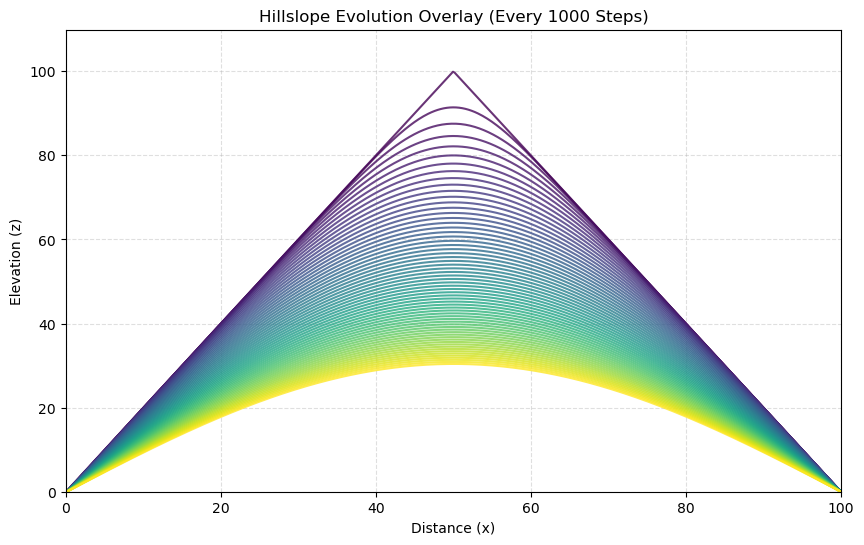

In [81]:
steps_per_overlay = 1000
frame_step = steps_per_overlay // save_interval

fig, ax = plt.subplots(figsize=(10, 6))

colors = cm.viridis(np.linspace(0, 1, len(z_ridge_store[::frame_step])))

for i, frame_idx in enumerate(range(0, len(z_ridge_store), frame_step)):
    ax.plot(x, z_ridge_store[frame_idx], 
            color=colors[i], 
            label=f'Step {frame_idx * save_interval}',
            alpha=0.8)

ax.set_title(f'Hillslope Evolution Overlay (Every {steps_per_overlay} Steps)')
ax.set_xlabel('Distance (x)')
ax.set_ylabel('Elevation (z)')
ax.set_xlim(0, L)
ax.set_ylim(0, np.max(z_ridge_store[0]) * 1.1)
ax.grid(True, linestyle='--', alpha=0.4)

plt.show()

**Finally, we investigate a cliff scenario, with a stream at the bottom (right)**

In [68]:
condlist = [x < 40, (x >= 40) & (x < 60), x >= 60]

funclist = [
    lambda x: -0.1 * x + 168,
    lambda x: -8.0 * x + 485,
    lambda x: -0.1 * x + 10
]

z_cliff_init = np.piecewise(x, condlist, funclist)

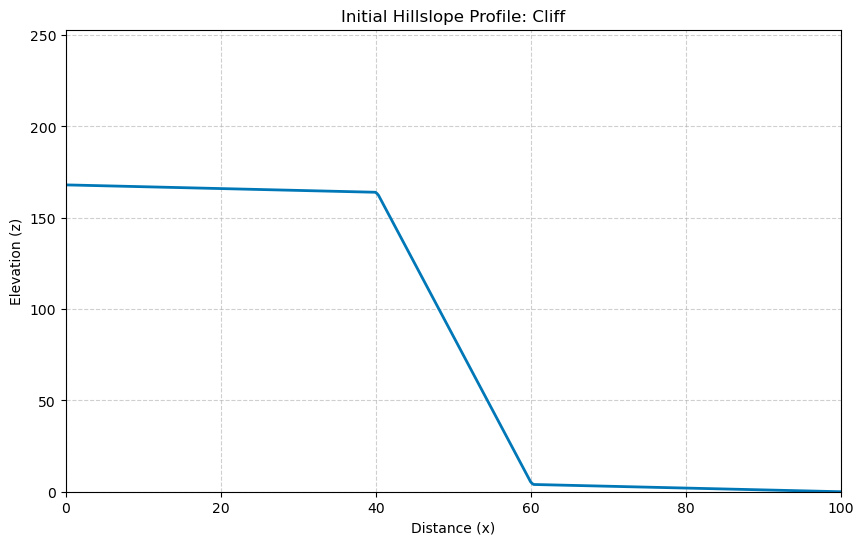

In [85]:
fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot(x, z_cliff_init, color='#0077b6', lw=2)

ax.set_title(f'Initial Hillslope Profile: Cliff')
ax.set_xlabel('Distance (x)')
ax.set_ylabel('Elevation (z)')
ax.set_xlim(0, max(x))
ax.set_ylim(0, np.max(z_cliff_init) * 1.5 + 1) 
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

**The modeling steps again remain the same, but still notice how the boundary conditions change**

In [70]:
D = .01

In [71]:
time_per_simulation = 100000
dt = 0.4 * (dx**2) / D
num_steps = int(time_per_simulation / dt)
save_interval = 100

In [72]:
z_cliff_store = [z_cliff_init.copy()]
z = z_cliff_init

for step in range(num_steps):

    d2zdx2 = np.zeros(nx)
    d2zdx2[1:-1] = (z[2:] - 2 * z[1:-1] + z[:-2]) / (dx**2)   # central difference formula for second derivative
    
    z += (D * d2zdx2) * dt                                    # hillslope diffusion equation
    
    z[-1] = 0.0                                               # right boundary condition, fixes base level (stream)
    z[0] = z[1]                                               # left boundary condition, no diffusion at hill top
    
    z = np.maximum(z, 0)
    
    if step % save_interval == 0:
        z_cliff_store.append(z.copy())

z_cliff_final = z.copy()

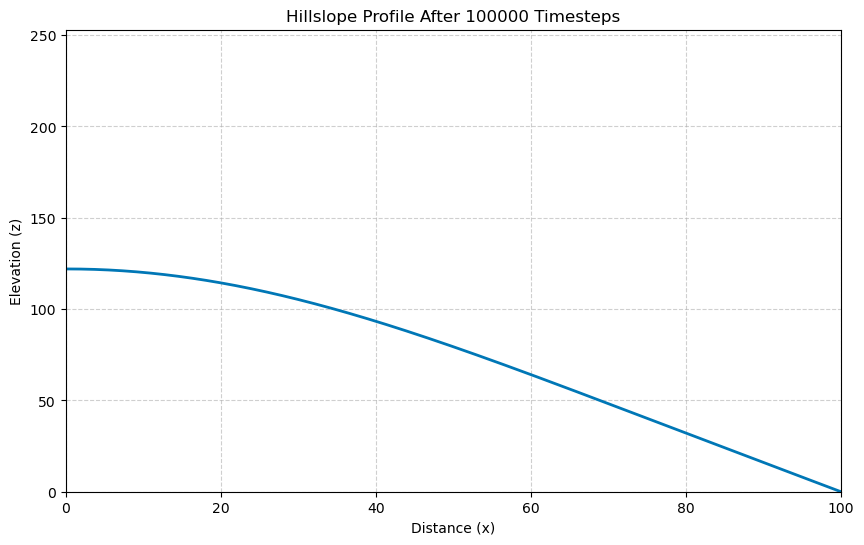

In [73]:
fig, ax = plt.subplots(figsize=(10, 6))
line, = ax.plot(x, z_cliff_final, color='#0077b6', lw=2)

ax.set_title(f'Hillslope Profile After {time_per_simulation} Timesteps')
ax.set_xlabel('Distance (x)')
ax.set_ylabel('Elevation (z)')
ax.set_xlim(0, max(x))
ax.set_ylim(0, np.max(z_cliff_init) * 1.5 + 1) 
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [74]:
def update(frame):
    line.set_ydata(z_cliff_store[frame])
    ax.set_title(f'Hillslope Evolution - Time: {frame * save_interval * dt:.0f}')
    return line,

ani = FuncAnimation(fig, update, frames=len(z_cliff_store), interval=50, blit=True)

print("Saving animation... this may take a moment.")
ani.save('hillslope_evolution_cliff.gif', writer='pillow', fps=20)
print("Animation saved as hillslope_evolution_cliff.gif")

Saving animation... this may take a moment.
Animation saved as hillslope_evolution_cliff.gif


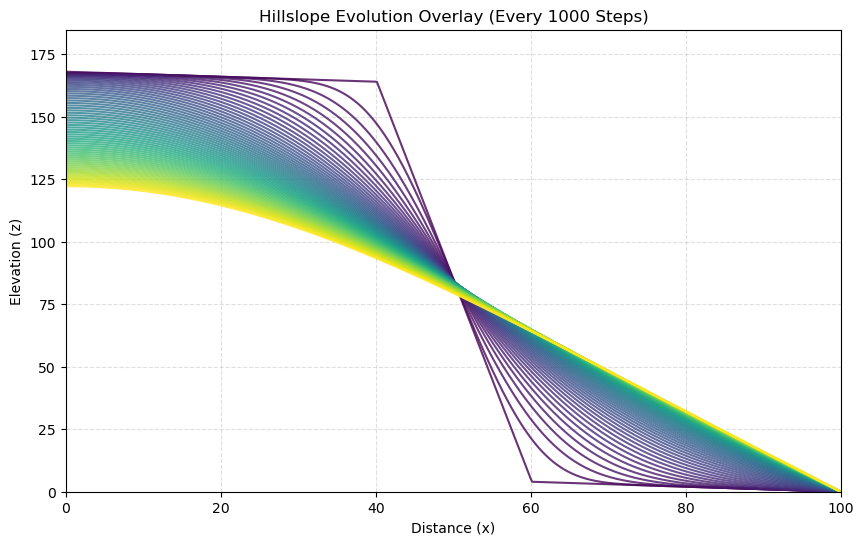

In [82]:
steps_per_overlay = 1000
frame_step = steps_per_overlay // save_interval

fig, ax = plt.subplots(figsize=(10, 6))

colors = cm.viridis(np.linspace(0, 1, len(z_cliff_store[::frame_step])))

for i, frame_idx in enumerate(range(0, len(z_cliff_store), frame_step)):
    ax.plot(x, z_cliff_store[frame_idx], 
            color=colors[i], 
            label=f'Step {frame_idx * save_interval}',
            alpha=0.8)

ax.set_title(f'Hillslope Evolution Overlay (Every {steps_per_overlay} Steps)')
ax.set_xlabel('Distance (x)')
ax.set_ylabel('Elevation (z)')
ax.set_xlim(0, L)
ax.set_ylim(0, np.max(z_cliff_store[0]) * 1.1)
ax.grid(True, linestyle='--', alpha=0.4)

plt.show()

In [ ]:
# next... spatially variable uplift? maybe